# Assignment 1: Linear Regression


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")
df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,6021
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,5914
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,4645
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,5831
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,6199


In [3]:
df.shape

(500, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         495 non-null    float64
 2   Num_Bedrooms        494 non-null    float64
 3   Num_Bathrooms       499 non-null    float64
 4   Num_Floors          497 non-null    float64
 5   Year_Built          498 non-null    float64
 6   Has_Garden          494 non-null    float64
 7   Has_Pool            499 non-null    float64
 8   Garage_Size         496 non-null    float64
 9   Location_Score      499 non-null    float64
 10  Distance_to_Center  499 non-null    float64
 11  Price               500 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 47.0 KB


In [5]:
df.isnull().sum()

ID                    0
Square_Feet           5
Num_Bedrooms          6
Num_Bathrooms         1
Num_Floors            3
Year_Built            2
Has_Garden            6
Has_Pool              1
Garage_Size           4
Location_Score        1
Distance_to_Center    1
Price                 0
dtype: int64

## Preprocessing

Here I filled missing values using the mean value of that column. I also removed the `ID` column because it is just an index and does not help in prediction.

In [6]:
df = df.fillna(df.mean())

df = df.drop("ID", axis=1)

df.isnull().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

##  Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.568172,2.955466,1.977956,1.963783,1957.734940,0.536437,0.490982,30.225806,5.156770,10.482469,5822.106000
std,74.575885,1.433230,0.819058,0.799985,35.398873,0.496166,0.499919,11.489710,2.848370,5.580831,1222.726482
min,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,2769.000000
25%,110.319923,2.000000,1.000000,1.000000,1926.750000,0.000000,0.000000,20.750000,2.760650,6.078574,5031.000000
50%,177.414749,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.186503,10.886066,5747.500000
75%,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.724980,15.072590,6659.500000
max,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,9607.000000


### Price distribution

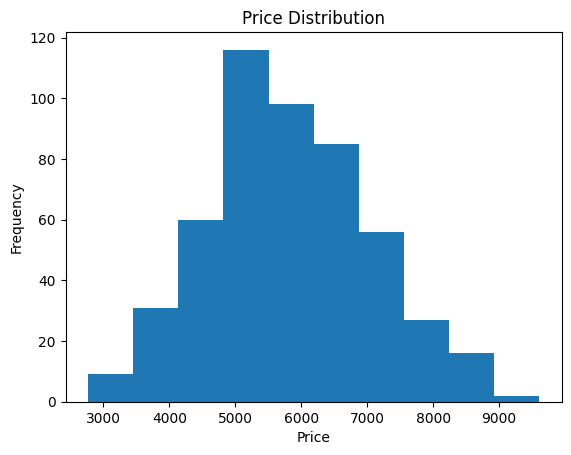

In [ ]:
plt.hist(df["Price"])
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

### Square Feet vs Price

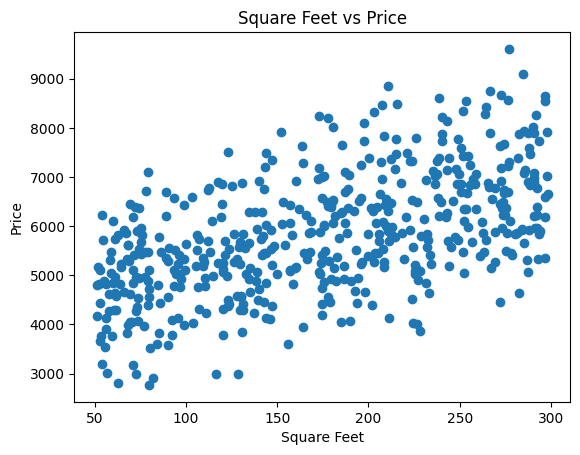

In [ ]:
plt.scatter(df["Square_Feet"], df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Square Feet vs Price")
plt.show()

### Correlation with Price

In [ ]:
df.corr()["Price"].sort_values(ascending=False)

Price                 1.000000
Num_Bedrooms          0.559894
Square_Feet           0.557757
Year_Built            0.411751
Num_Floors            0.177201
Num_Bathrooms         0.154483
Has_Pool              0.136693
Has_Garden            0.111362
Location_Score        0.074561
Garage_Size           0.026694
Distance_to_Center    0.001801
Name: Price, dtype: float64

## Preparing X and y

`Price` is the target variable. All other columns are used as input features.

In [11]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [12]:
feature_names = ["Intercept"] + list(X.columns)

X = X.values
y = y.values

In [13]:
# adding one column for intercept
ones = np.ones((X.shape[0], 1))
X = np.hstack((ones, X))

In [14]:
beta = np.linalg.inv(X.T @ X) @ X.T @ y
beta

array([-2.93253871e+04,  1.01705900e+01,  5.07616258e+02,  2.93648594e+02,
        2.06554769e+02,  1.53875277e+01,  3.00681963e+02,  4.76879350e+02,
        1.05404874e+01,  4.81557589e+01, -1.92438341e+01])

The values below are the intercept and coefficients.

In [15]:
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta
})
coef_table

,Feature,Coefficient
0,Intercept,-29325.387084
1,Square_Feet,10.170590
2,Num_Bedrooms,507.616258
3,Num_Bathrooms,293.648594
4,Num_Floors,206.554769
5,Year_Built,15.387528
6,Has_Garden,300.681963
7,Has_Pool,476.879350
8,Garage_Size,10.540487
9,Location_Score,48.155759


## Prediction

In [16]:
y_pred = X @ beta

y_pred[:5]

array([5979.81635594, 5842.64473902, 4891.81282354, 5876.58614312,
       6321.10988124])

## RSS & MSE


In [17]:
residuals = y - y_pred

RSS = np.sum(residuals ** 2)
MSE = np.mean(residuals ** 2)

print("RSS =", RSS)
print("MSE =", MSE)

RSS = 23888683.96382409
MSE = 47777.36792764818


##  Actual vs Predicted graph

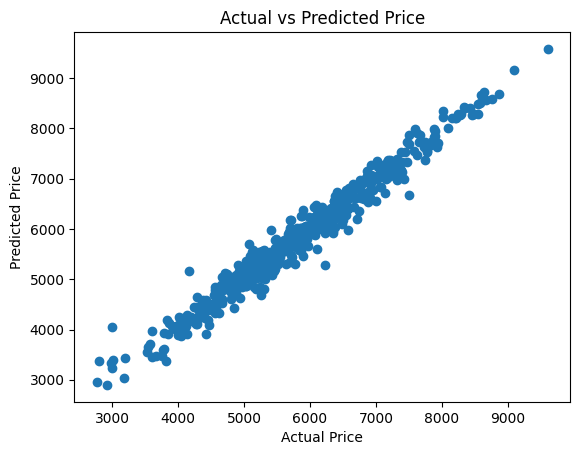

In [18]:
plt.scatter(y, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

##  Residual plot

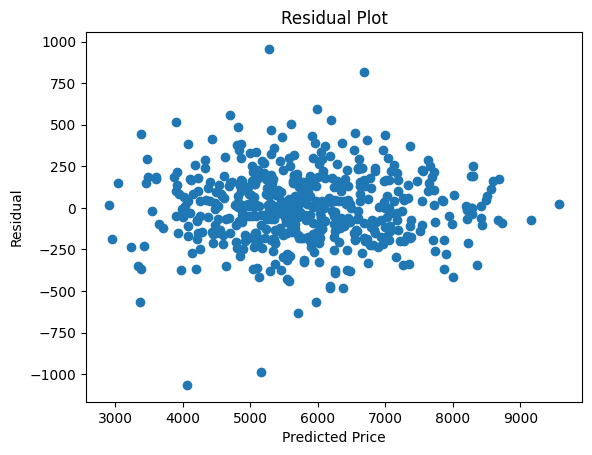

In [19]:
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()